In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from lightgbm import LGBMRegressor

In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

df=pd.read_csv("data.csv")
df.tail()

,Date,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,brent_ma_5,brent_ma_20,brent_ma_60,brent_vol_5d,high_low_range,crude_stock_level,gas_stock_level,dist_stock_level,crude_stock_wow_change,gas_stock_wow_change,dist_stock_wow_change,crude_stock_vs_5yr_avg,gas_stock_vs_5yr_avg,dist_stock_vs_5yr_avg,prod_weekly,prod_4w_ma,prod_wow_change,crude_exports,crude_imports,import_4w_ma,net_imports,refinery_run_rate,wti_mm_net_long,wti_mm_net_long_ratio,wti_producer_hedge_ratio,wti_mm_position_change_wow,wti_sentiment_position,DXY_DX-Y.NYB,XLE_XLE,VDE_VDE,IXC_IXC,"('DXY', 'DX-Y.NYB')_ret_1d","('XLE', 'XLE')_ret_1d","('VDE', 'VDE')_ret_1d","('IXC', 'IXC')_ret_1d",us10y_yield_x,us2y_yield_x,term_spread_x,us10y_yield_y,us2y_yield_y,term_spread_y,bdi_price,bdi_open,bdi_high,bdi_low,bdi_change_%
2976,2025-11-04,64.440002,60.560001,3.880001,-0.006935,0.000621,-0.015432,64.864000,63.7680,65.977833,0.005557,0.015673,421168.0,206009.0,206009.0,5202.0,-4729.0,-4729.0,-0.042602,-0.095804,-0.095804,13651.0,13640.0,0.000513,4367.0,5924.0,5604.5,1557.0,86.0,NaN,NaN,NaN,NaN,NaN,100.220001,87.190002,123.169998,41.279999,0.003505,-0.010778,-0.011635,-0.008646,4.10,3.58,0.52,4.10,3.58,0.52,1958.0,1958.0,1958.0,1958.0,0.67
2977,2025-11-05,63.520000,59.599998,3.920002,-0.014277,-0.021565,-0.041208,64.584000,63.6315,65.934500,0.006487,0.023772,421168.0,206009.0,206009.0,5202.0,-4729.0,-4729.0,-0.042602,-0.095804,-0.095804,13651.0,13640.0,0.000513,4367.0,5924.0,5604.5,1557.0,86.0,NaN,NaN,NaN,NaN,NaN,100.199997,87.419998,123.339996,41.450001,-0.000200,0.002638,0.001380,0.004118,4.17,3.63,0.54,4.17,3.63,0.54,2003.0,2003.0,2003.0,2003.0,2.30
2978,2025-11-06,63.380001,59.430000,3.950001,-0.002204,-0.024923,-0.028212,64.260001,63.5395,65.897000,0.005906,0.023667,421168.0,206009.0,206009.0,5202.0,-4729.0,-4729.0,-0.042602,-0.095804,-0.095804,13651.0,13640.0,0.000513,4367.0,5924.0,5604.5,1557.0,86.0,NaN,NaN,NaN,NaN,NaN,99.730003,88.269997,124.250000,41.700001,-0.004691,0.009723,0.007378,0.006031,4.11,3.57,0.54,4.11,3.57,0.54,2063.0,2063.0,2063.0,2063.0,3.00
2979,2025-11-07,63.630001,59.750000,3.880001,0.003944,-0.022130,0.014347,63.972001,63.5845,65.843500,0.006728,0.017916,421168.0,206009.0,206009.0,5202.0,-4729.0,-4729.0,-0.042602,-0.095804,-0.095804,13651.0,13640.0,0.000513,4367.0,5924.0,5604.5,1557.0,86.0,NaN,NaN,NaN,NaN,NaN,99.599998,89.540001,126.160004,42.439999,-0.001304,0.014388,0.015372,0.017746,NaN,NaN,NaN,NaN,NaN,NaN,2104.0,2104.0,2104.0,2104.0,1.99
2980,2025-11-10,64.190002,60.349998,3.840004,0.008801,-0.010787,0.013740,63.832001,63.6280,65.815833,0.009042,0.009191,421168.0,206009.0,206009.0,5202.0,-4729.0,-4729.0,-0.042602,-0.095804,-0.095804,13651.0,13640.0,0.000513,4367.0,5924.0,5604.5,1557.0,86.0,NaN,NaN,NaN,NaN,NaN,99.572998,NaN,NaN,NaN,-0.000271,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df["target_1d_ret"] = df["brent_close"].pct_change().shift(-1)
df["target_5d_ret"] = df["brent_close"].pct_change(5).shift(-5)

In [ ]:
df = pd.read_csv("data.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2981 entries, 0 to 2980
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        2981 non-null   datetime64[ns]
 1   brent_close                 2981 non-null   float64       
 2   wti_close                   2981 non-null   float64       
 3   brent_wti_spread            2981 non-null   float64       
 4   brent_ret_1d                2981 non-null   float64       
 5   brent_ret_5d                2981 non-null   float64       
 6   brent_ret_20d               2981 non-null   float64       
 7   brent_ma_5                  2981 non-null   float64       
 8   brent_ma_20                 2981 non-null   float64       
 9   brent_ma_60                 2981 non-null   float64       
 10  brent_vol_5d                2981 non-null   float64       
 11  high_low_range              2981 non-null   float64     

In [15]:
print(df["Date"].isna().sum())
print(df["Date"].duplicated().sum())

0
0


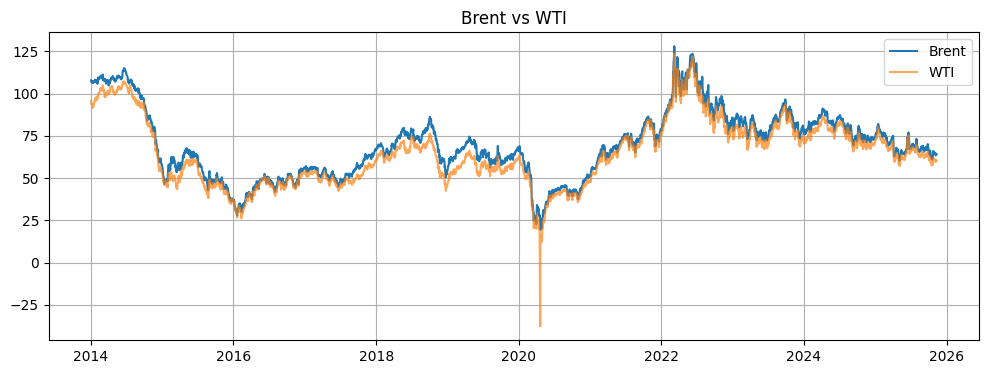

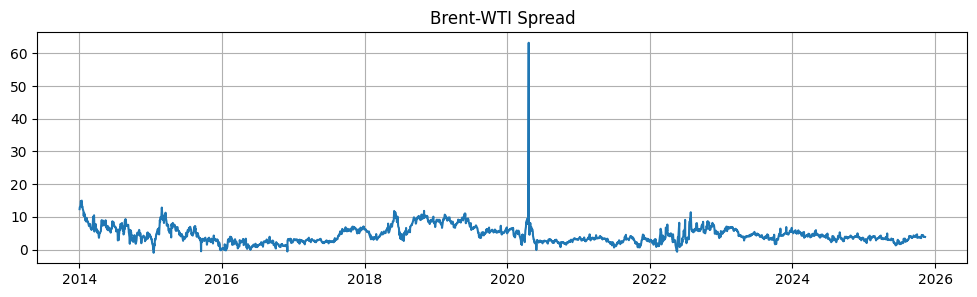

In [ ]:
# 유가, 스프레드

plt.figure(figsize=(12,4))
plt.plot(df["Date"], df["brent_close"], label="Brent")
plt.plot(df["Date"], df["wti_close"], label="WTI", alpha=0.7)
plt.legend(); plt.grid(True); plt.title("Brent vs WTI"); plt.show()

plt.figure(figsize=(12,3))
plt.plot(df["Date"], df["brent_wti_spread"])
plt.grid(True); plt.title("Brent-WTI Spread"); plt.show()


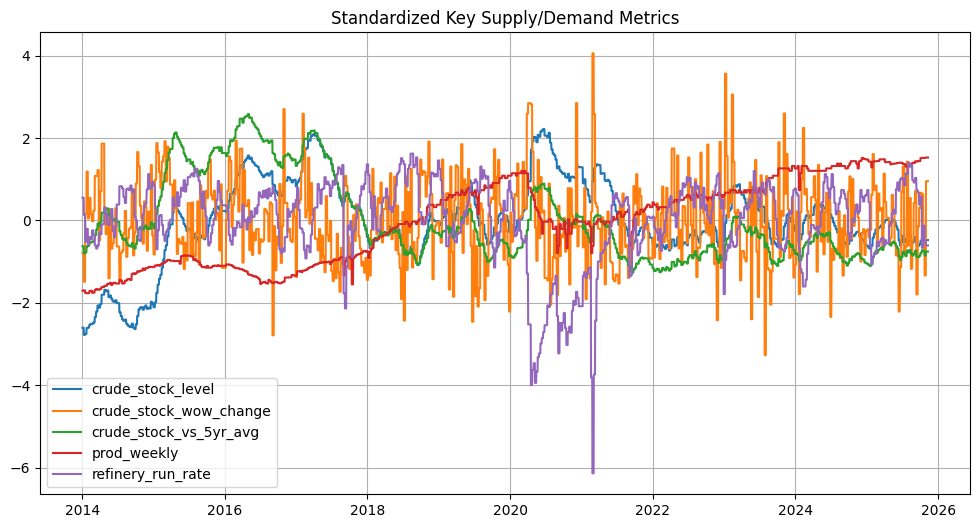

In [17]:
key_cols = [
    "crude_stock_level", "crude_stock_wow_change", "crude_stock_vs_5yr_avg",
    "prod_weekly", "refinery_run_rate"
]

plt.figure(figsize=(12,6))
for c in key_cols:
    if c in df.columns:
        plt.plot(df["Date"], (df[c] - df[c].mean()) / df[c].std(), label=c)
plt.legend(); plt.grid(True); plt.title("Standardized Key Supply/Demand Metrics"); plt.show()


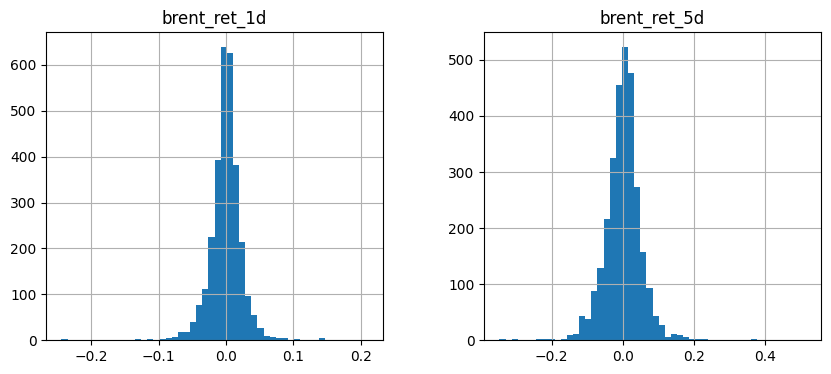

In [18]:
df["brent_ret_1d"] = df["brent_close"].pct_change()
df["brent_ret_5d"] = df["brent_close"].pct_change(5)

df[["brent_ret_1d", "brent_ret_5d"]].hist(bins=50, figsize=(10,4))
plt.show()


### 상관관계

In [19]:
df["y_ret_1d"] = df["brent_close"].pct_change().shift(-1)

corr = (
    df.drop(columns=["Date"])
      .corr(numeric_only=True)["y_ret_1d"]
      .sort_values(ascending=False)
)
print(corr.head(20))
print(corr.tail(20))


y_ret_1d                      1.000000
('VDE', 'VDE')_ret_1d         0.057134
high_low_range                0.054616
('IXC', 'IXC')_ret_1d         0.054329
('XLE', 'XLE')_ret_1d         0.052815
gas_stock_level               0.044453
dist_stock_level              0.044453
crude_stock_level             0.044252
bdi_change_%                  0.031255
wti_sentiment_position        0.031176
gas_stock_vs_5yr_avg          0.029524
dist_stock_vs_5yr_avg         0.029524
brent_vol_5d                  0.025935
('DXY', 'DX-Y.NYB')_ret_1d    0.019050
crude_stock_vs_5yr_avg        0.014934
brent_ret_5d                  0.012977
bdi_price                     0.012941
bdi_low                       0.012277
bdi_high                      0.012273
bdi_open                      0.012273
Name: y_ret_1d, dtype: float64
wti_mm_net_long_ratio        -0.013609
import_4w_ma                 -0.014550
us2y_yield_y                 -0.017121
us2y_yield_x                 -0.017121
wti_mm_net_long              -0.0

In [20]:
target = df["brent_close"].pct_change().shift(-1)

candidates = [
    "crude_stock_wow_change",
    "crude_stock_vs_5yr_avg",
    "prod_weekly",
    "refinery_run_rate",
    "wti_mm_net_long_ratio",
    "DXY_DX-Y.NYB",
]

for col in candidates:
    if col not in df.columns:
        continue
    print(f"\n=== {col} ===")
    for lag in [0, 1, 3, 5]:
        corr = df[col].shift(lag).corr(target)
        print(f"lag {lag}: {corr:.4f}")



=== crude_stock_wow_change ===
lag 0: -0.0301
lag 1: -0.0083
lag 3: 0.0205
lag 5: 0.0149

=== crude_stock_vs_5yr_avg ===
lag 0: 0.0149
lag 1: 0.0173
lag 3: 0.0204
lag 5: 0.0179

=== prod_weekly ===
lag 0: -0.0109
lag 1: -0.0099
lag 3: -0.0092
lag 5: -0.0084

=== refinery_run_rate ===
lag 0: -0.0432
lag 1: -0.0491
lag 3: -0.0526
lag 5: -0.0456

=== wti_mm_net_long_ratio ===
lag 0: -0.0136
lag 1: -0.0252
lag 3: -0.0226
lag 5: 0.0015

=== DXY_DX-Y.NYB ===
lag 0: -0.0053
lag 1: -0.0069
lag 3: -0.0073
lag 5: -0.0042


In [ ]:
df["mm_extreme_long"] = (df["wti_mm_net_long_ratio"] > 0.8).astype(int)
df["mm_extreme_short"] = (df["wti_mm_net_long_ratio"] < 0.2).astype(int)
df["dxy_ret_1d"] = df["DXY_DX-Y.NYB"].pct_change()
df["xle_ret_1d"] = df["XLE_XLE"].pct_change()
df["yield_curve_inversion"] = (df["term_spread_x"] < 0).astype(int)
